<a href="https://colab.research.google.com/github/kfafa2018-ux/AIML-1030/blob/main/Week_10_Neural_Networks_Update.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning

In this notebook, we'll go through the code to create your very first neural network to predict whether the house price is below or above median value. We will go through the following in this notebook:

- Exploring and Processing the Data
- Building and Training our Neural Network
- Visualizing Loss and Accuracy
- Adding Regularization to our Neural Network

The code is annotated throughout the notebook and you simply need to download the dataset [here](https://drive.google.com/file/d/1GfvKA0qznNVknghV4botnNxyH-KvODOC/view), put the dataset in the same folder as this notebook and run the code cells below.

**Before we code any ML algorithm, the first thing we need to do is to put our data in a format that the algorithm will want. In particular, we need to:**

- Read in the CSV (comma separated values) file and convert them to arrays. Arrays are a data format that our algorithm can process.
- Split our dataset into the input features (which we call x) and the label (which we call y).
- Scale the data (we call this normalization) so that the input features have similar orders of magnitude.
- Split our dataset into the training set, the validation set and the test set.

# Exploring and Processing the Data

We first have to read in the CSV file that we've been given. We'll use a package called pandas for that:

In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/AIML 1030/Week 10/Week 10/OneDrive_1_3-28-2026/Week 10 Dependencies/diabetes.csv')

In [4]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


Here, you can explore the data a little. We have our input features in the first ten columns:

- Lot Area (in sq ft)
- Overall Quality (scale from 1 to 10)
- Overall Condition (scale from 1 to 10)
- Total Basement Area (in sq ft)
- Number of Full Bathrooms
- Number of Half Bathrooms
- Number of Bedrooms above ground
- Total Number of Rooms above ground
- Number of Fireplaces
- Garage Area (in sq ft)


In our last column, we have **the feature that we would like to predict:**

**Is the house price above the median or not? (1 for yes and 0 for no)**


The dataset that we have now is in what we call a pandas dataframe. To convert it to an array, simply access its values:

In [5]:
dataset = df.values
#notes from class can only use numbers in a neural network, not data frames.

In [6]:
dataset

array([[  6.   , 148.   ,  72.   , ...,   0.627,  50.   ,   1.   ],
       [  1.   ,  85.   ,  66.   , ...,   0.351,  31.   ,   0.   ],
       [  8.   , 183.   ,  64.   , ...,   0.672,  32.   ,   1.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,   0.245,  30.   ,   0.   ],
       [  1.   , 126.   ,  60.   , ...,   0.349,  47.   ,   1.   ],
       [  1.   ,  93.   ,  70.   , ...,   0.315,  23.   ,   0.   ]])

Now, we split the dataset into our input features and the label we wish to predict.

We now split our dataset into input features (X) and the feature we wish to predict (Y). To do that split, we simply assign the first 10 columns of our array to a variable called X and the last column of our array to a variable called Y.

The code to do the first assignment is this:

In [7]:
X = dataset[:,0:8]
Y = dataset[:,8]

Normalizing our data is very important, as we want the input features to be on the same order of magnitude to make our training easier. We'll use a min-max scaler from scikit-learn which scales our data to be between 0 and 1.

In [8]:
from sklearn import preprocessing

In [9]:
min_max_scaler = preprocessing.MinMaxScaler()
X_scale = min_max_scaler.fit_transform(X)

In [10]:
X_scale

array([[0.35294118, 0.74371859, 0.59016393, ..., 0.50074516, 0.23441503,
        0.48333333],
       [0.05882353, 0.42713568, 0.54098361, ..., 0.39642325, 0.11656704,
        0.16666667],
       [0.47058824, 0.91959799, 0.52459016, ..., 0.34724292, 0.25362938,
        0.18333333],
       ...,
       [0.29411765, 0.6080402 , 0.59016393, ..., 0.390462  , 0.07130658,
        0.15      ],
       [0.05882353, 0.63316583, 0.49180328, ..., 0.4485842 , 0.11571307,
        0.43333333],
       [0.05882353, 0.46733668, 0.57377049, ..., 0.45305514, 0.10119556,
        0.03333333]])

Lastly, we wish to set aside some parts of our dataset for a validation set and a test set. We use the function train_test_split from scikit-learn to do that.

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_val_and_test, Y_train, Y_val_and_test = train_test_split(X_scale, Y, test_size=0.3)

In [13]:
X_val, X_test, Y_val, Y_test = train_test_split(X_val_and_test, Y_val_and_test, test_size=0.5)

In summary, we now have a total of six variables for our datasets we will use:

- X_train (10 input features, 70% of full dataset)
- X_val (10 input features, 15% of full dataset)
- X_test (10 input features, 15% of full dataset)
- Y_train (1 label, 70% of full dataset)
- Y_val (1 label, 15% of full dataset)
- Y_test (1 label, 15% of full dataset)

In [14]:
print(X_train.shape, X_val.shape, X_test.shape, Y_train.shape, Y_val.shape, Y_test.shape)

(537, 8) (115, 8) (116, 8) (537,) (115,) (116,)


# Building and Training Our First Neural Network

We will be using Keras to build our architecture. Let's import the code from Keras that we will need to use:

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

We will be using the Sequential model, which means that we merely need to describe the layers above in sequence. Our neural network has three layers:

![H3eAYjXcA2asaCjCYrVT7lc2IIBQGQWzQlPG.png](attachment:H3eAYjXcA2asaCjCYrVT7lc2IIBQGQWzQlPG.png)

- Hidden layer 1: 32 neurons, ReLU activation
- Hidden layer 2: 32 neurons, ReLU activation
- Output Layer: 1 neuron, Sigmoid activation

In [16]:
model = Sequential([
    Input(shape=(8,)),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid'),
])
#dense means they are fully connected layers

Now that we've got our architecture specified, we need to find the best numbers for it. Before we start our training, we have to configure the model by
- Telling it what algorithm you want to use to do the optimization (we'll use stochastic gradient descent)
- Telling it what loss function to use (for binary classification, we will use binary cross entropy)
- Telling it what other metrics you want to track apart from the loss function (we want to track accuracy as well)

We do so below:

In [17]:
model.compile(optimizer='sgd',
              loss='binary_crossentropy',
              metrics=['accuracy'])
#These are the hyper parameters
#compile means to put it into machine code

Training on the data is pretty straightforward and requires us to write one line of code. The function is called 'fit' as we are fitting the parameters to the data. We specify:
- what data we are training on, which is X_train and Y_train
- the size of our mini-batch
- how long we want to train it for (epochs)
- what our validation data is so that the model will tell us how we are doing on the validation data at each point.

This function will output a history, which we save under the variable hist. We'll use this variable a little later.

In [18]:
hist = model.fit(X_train, Y_train,
          batch_size=32, epochs=100,
          validation_data=(X_val, Y_val))
#Training the model
#X holds th inputs of what we are trying to predict with
#Y is the output of what we are trying to predict from
#hist means history and is an object that is a representation of all the numbers being printed and stored in a history list
#epoch means hyperparameter dedtermining how many times the learning algorithm works through the entire data set

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3464 - loss: 0.7032 - val_accuracy: 0.4348 - val_loss: 0.6968
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4767 - loss: 0.6931 - val_accuracy: 0.5913 - val_loss: 0.6882
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6741 - loss: 0.6848 - val_accuracy: 0.6696 - val_loss: 0.6812
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6648 - loss: 0.6780 - val_accuracy: 0.6609 - val_loss: 0.6757
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6648 - loss: 0.6723 - val_accuracy: 0.6522 - val_loss: 0.6708
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6648 - loss: 0.6675 - val_accuracy: 0.6522 - val_loss: 0.6670
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6648 - loss: 0.6634 - val_accuracy: 0.6522 - val_loss: 0.6638
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6629 - loss: 0.6602 - val_accuracy: 0.6

Evaluating our data on the test set:

In [19]:
model.evaluate(X_test, Y_test)[1]
#this is evaluating the test set and is called through the validate function in following code blocks

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5948 - loss: 0.6390 


0.5948275923728943

# Visualizing Loss and Accuracy

Import the relevant package we need to do the visualization

In [20]:
import matplotlib.pyplot as plt

We want to visualize the training loss and the validation loss like this:

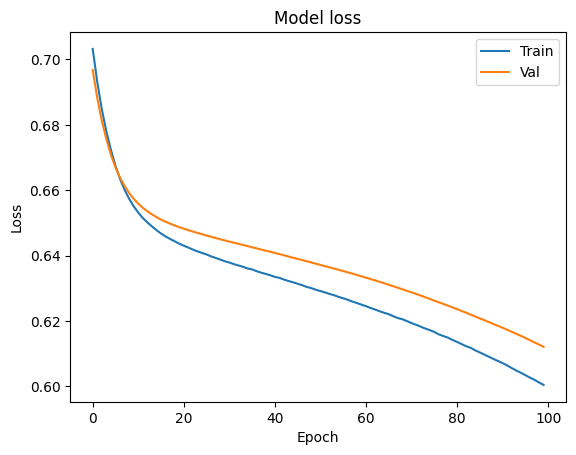

In [21]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()
#the elbow shape means it's been training too long and will flatten out.
#val_loss calls the above evaluate set

We can also visualize the training accuracy and the validation accuracy like this:

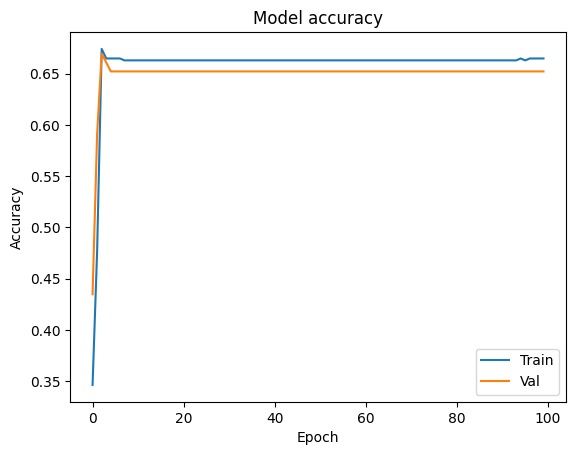

In [22]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

# Adding Regularization to our Neural Network

We'll train a model which will overfit, which we call Model 2. This might take a few minutes.

In [23]:
import tensorflow as tf

model_2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(8,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])
model_2.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
hist_2 = model_2.fit(X_train, Y_train,
          batch_size=32, epochs=50, # Reduced epochs and increased batch size
          validation_data=(X_val, Y_val))

Epoch 1/75
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 286ms/step - accuracy: 0.6629 - loss: 0.6895 - val_accuracy: 0.6522 - val_loss: 0.6457
Epoch 2/75
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 301ms/step - accuracy: 0.6574 - loss: 0.6270 - val_accuracy: 0.6522 - val_loss: 0.6687
Epoch 3/75
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 328ms/step - accuracy: 0.6816 - loss: 0.5762 - val_accuracy: 0.4609 - val_loss: 0.6807
Epoch 4/75
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 297ms/step - accuracy: 0.6201 - loss: 0.6391 - val_accuracy: 0.6522 - val_loss: 0.6104
Epoch 5/75
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 254ms/step - accuracy: 0.6518 - loss: 0.6444 - val_accuracy: 0.6522 - val_loss: 0.6545
Epoch 6/75
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 306ms/step - accuracy: 0.6816 - loss: 0.5912 - val_accuracy: 0.6522 - val_loss: 0.6011
Epoch 7/75
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 271ms/step - accuracy: 0.6890 - loss: 0.5833 - val_accuracy: 0.7217 - val_loss: 0.5050
Epoch 8/75
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 227ms/step - accuracy: 0.7207 - loss: 0.5416 - val_accuracy:

### Using PCA for Dimensionality Reduction to Speed Up Training

Principal Component Analysis (PCA) is a technique used to reduce the dimensionality of data while retaining most of its variance. By reducing the number of input features, we can potentially speed up the training of our neural network, as the model will have fewer parameters to learn and fewer computations per epoch.

In [31]:
from sklearn.decomposition import PCA

# Initialize PCA with a chosen number of components.
# We had 8 features, let's reduce it to 4 to demonstrate significant reduction.
pca = PCA(n_components=4)

# Fit PCA on the training data and transform all datasets
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

print(f"Original X_train shape: {X_train.shape}")
print(f"PCA transformed X_train shape: {X_train_pca.shape}")
print(f"PCA transformed X_val shape: {X_val_pca.shape}")
print(f"PCA transformed X_test shape: {X_test_pca.shape}")

Original X_train shape: (537, 8)
PCA transformed X_train shape: (537, 4)
PCA transformed X_val shape: (115, 4)
PCA transformed X_test shape: (116, 4)


Now, we will define a new model, `model_pca`, similar to `model_2` but with an adjusted input layer to match the 4 PCA components. This will demonstrate how training time can be reduced with fewer input features.

In [32]:
import tensorflow as tf

model_pca = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_pca.shape[1],)), # Input shape matches PCA components
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

model_pca.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Training model with PCA-transformed data...")

hist_pca = model_pca.fit(X_train_pca, Y_train,
          batch_size=32, epochs=50, # Using the same epochs and batch size as the faster model_2
          validation_data=(X_val_pca, Y_val))

print("Evaluation on test set with PCA-transformed data:")
model_pca.evaluate(X_test_pca, Y_test)[1]

Training model with PCA-transformed data...
Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.7132 - loss: 0.6679 - val_accuracy: 0.7130 - val_loss: 0.6414
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7207 - loss: 0.6101 - val_accuracy: 0.7304 - val_loss: 0.5724
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7356 - loss: 0.5384 - val_accuracy: 0.7391 - val_loss: 0.5253
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7356 - loss: 0.5112 - val_accuracy: 0.7478 - val_loss: 0.5076
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7486 - loss: 0.4968 - val_accuracy: 0.7304 - val_loss: 0.5045
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7542 - loss: 0.4915 - val_accuracy: 0.7391 - val_loss: 0.5043
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7542 - loss: 0.4855 - val_accuracy: 0.7391 - val_loss: 0.5013
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.76

0.7241379022598267

You can compare the training time of `model_pca` with `model_2` by observing the epoch durations. Generally, with fewer input features, each epoch should complete faster, leading to a quicker overall training process, assuming similar model complexity and number of epochs.

### Experimenting with different `n_components` for PCA

To see how the number of principal components affects both training speed and model accuracy, you can modify the `n_components` variable below. After changing its value, re-run the following cells to observe the new PCA transformation, model training, and evaluation results.

In [35]:
# @title Choose the number of PCA components (Run this cell to update) { run: 'auto' }
selected_n_components = 6 # @param {type: "integer"}

# Re-initialize PCA with the selected number of components
pca_experiment = PCA(n_components=selected_n_components)

# Fit PCA on the training data and transform all datasets
X_train_pca_exp = pca_experiment.fit_transform(X_train)
X_val_pca_exp = pca_experiment.transform(X_val)
X_test_pca_exp = pca_experiment.transform(X_test)

print(f"Original X_train shape: {X_train.shape}")
print(f"PCA transformed X_train shape with {selected_n_components} components: {X_train_pca_exp.shape}")
print(f"PCA transformed X_val shape with {selected_n_components} components: {X_val_pca_exp.shape}")
print(f"PCA transformed X_test shape with {selected_n_components} components: {X_test_pca_exp.shape}")

Original X_train shape: (537, 8)
PCA transformed X_train shape with 6 components: (537, 6)
PCA transformed X_val shape with 6 components: (115, 6)
PCA transformed X_test shape with 6 components: (116, 6)


Now, we will define and train a new model using the data transformed with the selected `n_components`. This will allow you to see the impact of changing the number of components on the model's performance and training time.

In [36]:
import tensorflow as tf

model_pca_exp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_pca_exp.shape[1],)), # Input shape matches selected PCA components
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

model_pca_exp.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print(f"Training model with PCA-transformed data ({selected_n_components} components)...")

hist_pca_exp = model_pca_exp.fit(X_train_pca_exp, Y_train,
          batch_size=32, epochs=50, # Keep epochs and batch size consistent for comparison
          validation_data=(X_val_pca_exp, Y_val))

print("Evaluation on test set with PCA-transformed data:")
loss, accuracy = model_pca_exp.evaluate(X_test_pca_exp, Y_test)
print(f"Test Accuracy with {selected_n_components} PCA components: {accuracy:.4f}")

Training model with PCA-transformed data (6 components)...
Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6238 - loss: 0.6737 - val_accuracy: 0.6609 - val_loss: 0.6474
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7132 - loss: 0.6121 - val_accuracy: 0.7130 - val_loss: 0.5783
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7393 - loss: 0.5395 - val_accuracy: 0.7478 - val_loss: 0.5198
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7784 - loss: 0.4928 - val_accuracy: 0.7304 - val_loss: 0.4991
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7654 - loss: 0.4856 - val_accuracy: 0.7478 - val_loss: 0.4988
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7821 - loss: 0.4795 - val_accuracy: 0.7478 - val_loss: 0.4891
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7858 - loss: 0.4723 - val_accuracy: 0.7478 - val_loss: 0.4883
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accura

Visualize the loss and accuracy for the model trained with the chosen number of PCA components.

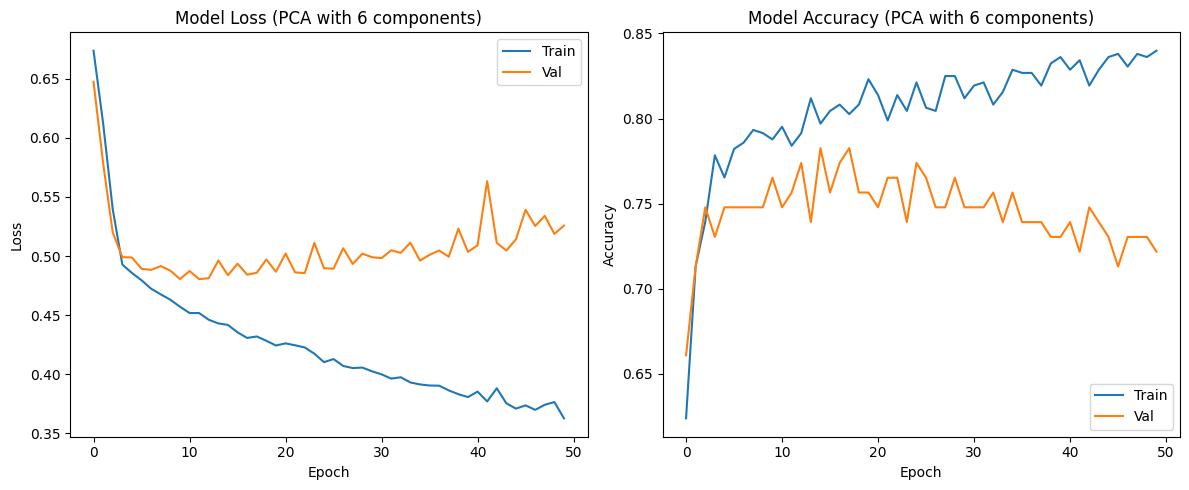

In [37]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_pca_exp.history['loss'])
plt.plot(hist_pca_exp.history['val_loss'])
plt.title(f'Model Loss (PCA with {selected_n_components} components)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')

plt.subplot(1, 2, 2)
plt.plot(hist_pca_exp.history['accuracy'])
plt.plot(hist_pca_exp.history['val_accuracy'])
plt.title(f'Model Accuracy (PCA with {selected_n_components} components)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')

plt.tight_layout()
plt.show()

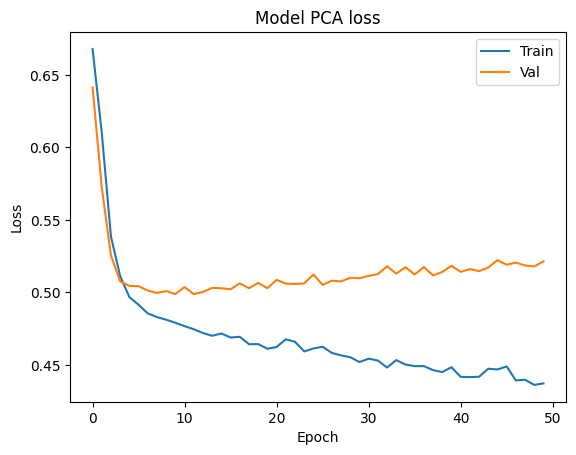

In [33]:
plt.plot(hist_pca.history['loss'])
plt.plot(hist_pca.history['val_loss'])
plt.title('Model PCA loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

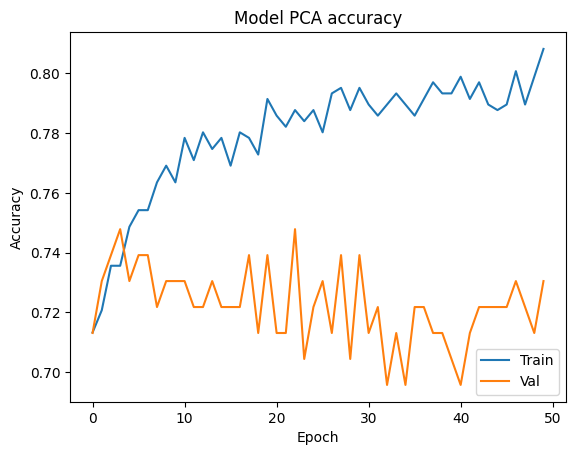

In [34]:
plt.plot(hist_pca.history['accuracy'])
plt.plot(hist_pca.history['val_accuracy'])
plt.title('Model PCA accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

Let's do the same visualization to see what overfitting looks like in terms of the loss and accuracy.

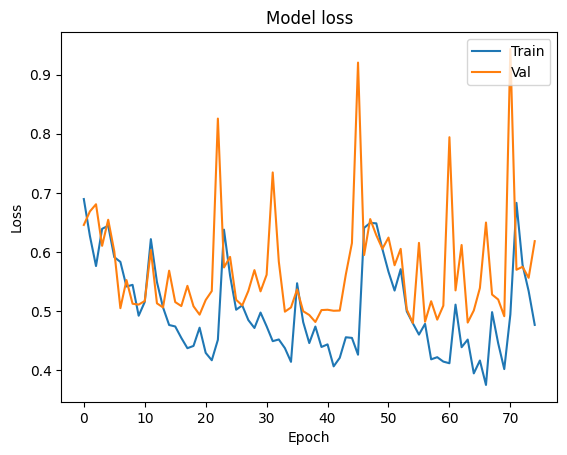

In [24]:
plt.plot(hist_2.history['loss'])
plt.plot(hist_2.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

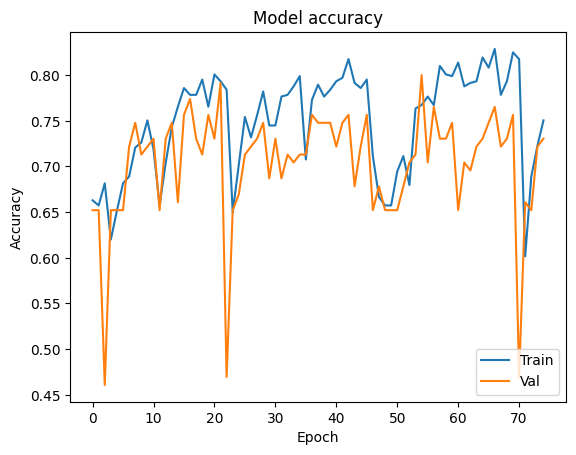

In [25]:
plt.plot(hist_2.history['accuracy'])
plt.plot(hist_2.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

To address the overfitting we see in Model 2, we'll incorporate L2 regularization and dropout in our third model here (Model 3).

In [26]:
from keras.layers import Dropout
from keras import regularizers

In [27]:
model_3 = Sequential([
    Input(shape=(8,)),
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.01)),
])

In [28]:
model_3.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
hist_3 = model_3.fit(X_train, Y_train,
          batch_size=32, epochs=100,
          validation_data=(X_val, Y_val))

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.6406 - loss: 20.4398 - val_accuracy: 0.6522 - val_loss: 11.1501
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.6629 - loss: 6.8280 - val_accuracy: 0.6522 - val_loss: 3.3783
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.6629 - loss: 2.0849 - val_accuracy: 0.6522 - val_loss: 1.1675
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.6629 - loss: 0.8939 - val_accuracy: 0.6522 - val_loss: 0.7246
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.6629 - loss: 0.6807 - val_accuracy: 0.6522 - val_loss: 0.6648
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.6629 - loss: 0.6551 - val_accuracy: 0.6522 - val_loss: 0.6566
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.6629 - loss: 0.6501 - val_accuracy: 0.6522 - val_loss: 0.6556
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.6629 - loss: 0.6471 - val_accuracy:

We'll now plot the loss and accuracy graphs for Model 3. You'll notice that the loss is a lot higher at the start, and that's because we've changed our loss function. To plot such that the window is zoomed in between 0 and 1.2 for the loss, we add an additional line of code (plt.ylim) when plotting

In [ ]:
plt.plot(hist_3.history['loss'])
plt.plot(hist_3.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.ylim(top=1.2, bottom=0)
plt.show()

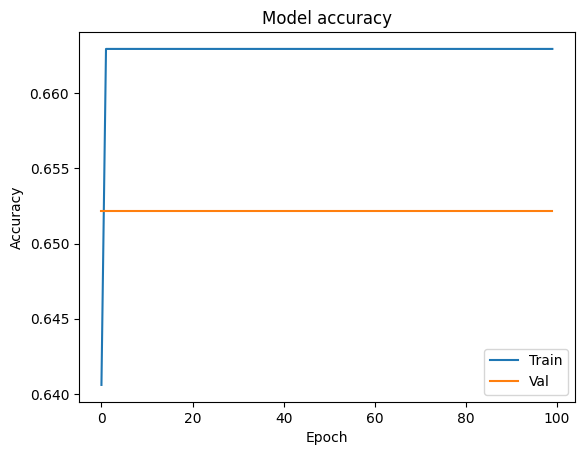

In [30]:
plt.plot(hist_3.history['accuracy'])
plt.plot(hist_3.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

As compared to Model 2, you should see that there's less overfitting!

# Exercise 1
Try to change the following Hyperparameters: <br>
batch_size <br>
epochs <br>
What is your observation?

# Exercise 2
Try to change the following parameters: <br>
No. of Hideen Layers <br>
Neurons in each Hidden Layer <br>
What is your observation?

My findings, the model took longer to train with additional hidden layers and neurons even though I lowered the epochs and batch size.